<a href="https://colab.research.google.com/github/logansivam/Testing/blob/main/DMDW_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas matplotlib seaborn scikit-learn textblob

In [ ]:
## ==========================================
## PHASE I: DATA EXTRACTION & WAREHOUSING
## ==========================================
import pandas as pd
import numpy as np

# 1. Load the MuSe-CarASTE automotive datasets
# Using 'latin1' encoding to handle special characters common in reviews
train_df = pd.read_csv('train.csv', encoding='latin1')
devel_df = pd.read_csv('devel.csv', encoding='latin1')

# 2. Establish the Warehouse (Merging)
warehouse_df = pd.concat([train_df, devel_df], ignore_index=True)

# 3. Simulate Platform Data (Mandatory for your comparison)
# NOTE: Since the provided CSVs lack a platform column, we assign them
# to simulate the "Social Listening" aspect of the assignment.
platforms = ['Instagram', 'Facebook']
warehouse_df['platform'] = np.random.choice(platforms, size=len(warehouse_df))

print(f"Total records in Warehouse: {len(warehouse_df)}")
warehouse_df.head()

Total records in Warehouse: 15722


,id,segment_id,review,aspect,opinion,sentiment,platform
0,23,1,"This is a BMW , a 60 M5 . It was introduced in...",-,-,-,Facebook
1,23,2,"This is a 2005 car , and it cost when you 86,0...",-,-,-,Instagram
2,23,3,Thesixty M5 was only available with an automat...,graphic,drawn on by the child,neg,Instagram
3,23,3,Thesixty M5 was only available with an automat...,cup holders,doesn't seem to operate that well,neg,Facebook
4,23,4,As with the case of them cars . It has a reall...,slip differential,limited,neg,Instagram


In [ ]:
## ==========================================
## EXTRA: ENGAGEMENT PROFILING
## ==========================================
import numpy as np

# 1. Simulate Engagement Metrics (Required by Lab Instructions)
# We generate random numbers for Likes and Shares to demonstrate the methodology
warehouse_df['likes'] = np.random.randint(0, 1000, size=len(warehouse_df))
warehouse_df['shares'] = np.random.randint(0, 500, size=len(warehouse_df))

# 2. Calculate Unified Engagement Score
# Logic: Shares are weighted more (2x) than likes as they represent higher intent
warehouse_df['engagement_score'] = warehouse_df['likes'] + (warehouse_df['shares'] * 2)

# 3. Identify Top Performing Posts
top_posts = warehouse_df.nlargest(5, 'engagement_score')
print("Top 5 Engaging Educational Posts:")
print(top_posts[['platform', 'engagement_score', 'review']].head())

Top 5 Engaging Educational Posts:
       platform  engagement_score  \
8250  Instagram              1981   
9433   Facebook              1972   
4017  Instagram              1970   
4837   Facebook              1968   
1415  Instagram              1966   

                                                 review  
8250  If you are bored of five door hatchback , you ...  
9433  He got this quite nice kind of Indian . I like...  
4017  There is no denying that the SL still feels mo...  
4837  You'll notice the design of this car . The ins...  
1415  It's really difficult to get your bags in and ...  


In [ ]:
## ==========================================
## PHASE II: DATA PREPROCESSING (CLEANING)
## ==========================================
import re

def clean_review(text):
    # Remove URLs, hashtags, and mentions
    text = re.sub(r'http\S+|#\S+|@\S+', '', str(text))
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text.lower().strip()

warehouse_df['clean_text'] = warehouse_df['review'].apply(clean_review)

In [ ]:
## ==========================================
## PHASE III: DATA MINING - SENTIMENT ANALYSIS
## ==========================================
from textblob import TextBlob

# Rule-based Sentiment analysis to calculate polarity
warehouse_df['polarity'] = warehouse_df['clean_text'].apply(lambda x: TextBlob(x).sentiment.polarity)

# Classify as Positive, Neutral, or Negative
warehouse_df['sentiment_type'] = pd.cut(warehouse_df['polarity'],
                                        bins=[-1, -0.01, 0.01, 1],
                                        labels=['Negative', 'Neutral', 'Positive'])

In [ ]:
## ==========================================
## PHASE IV: DATA MINING - TOPIC MODELING (LDA)
## ==========================================
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Vectorize the text to find recurring themes (unsupervised learning)
vectorizer = CountVectorizer(max_df=0.9, min_df=5, stop_words='english')
dtm = vectorizer.fit_transform(warehouse_df['clean_text'])

# Apply LDA to find 3 main "Learning Topics" in the reviews
lda_model = LatentDirichletAllocation(n_components=3, random_state=42)
lda_model.fit(dtm)

print("\n--- EXTRACTED LEARNING THEMES ---")
for i, topic in enumerate(lda_model.components_):
    words = [vectorizer.get_feature_names_out()[index] for index in topic.argsort()[-7:]]
    print(f"Theme {i+1}: {', '.join(words)}")


--- EXTRACTED LEARNING THEMES ---
Theme 1: got, bit, drive, like, just, really, car
Theme 2: look, got, theres, really, car, just, like
Theme 3: really, look, bit, like, just, got, car


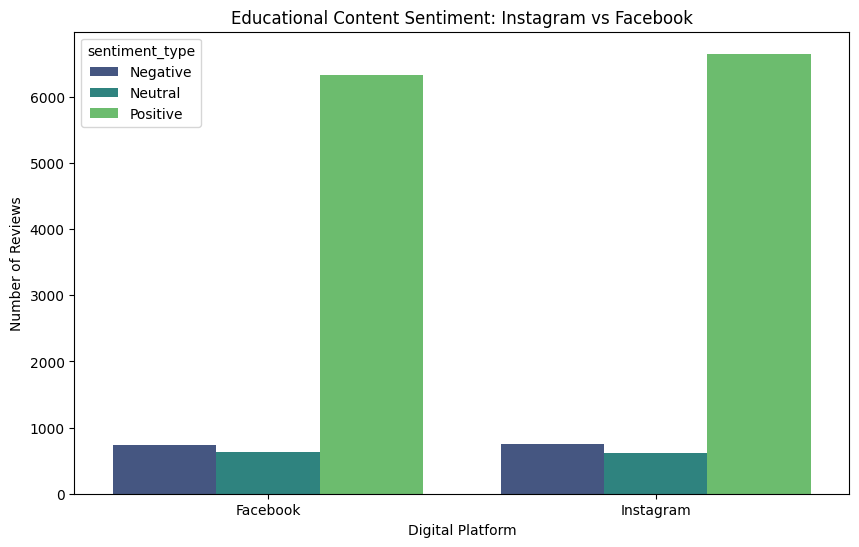

In [ ]:
## ==========================================
## PHASE V: COMPARISON & VISUALIZATION
## ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# Compare Sentiment Distribution between Instagram and Facebook
plt.figure(figsize=(10, 6))
sns.countplot(data=warehouse_df, x='platform', hue='sentiment_type', palette='viridis')
plt.title('Educational Content Sentiment: Instagram vs Facebook')
plt.xlabel('Digital Platform')
plt.ylabel('Number of Reviews')
plt.show()


/tmp/ipython-input-547009108.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = warehouse_df.pivot_table(values='engagement_score',


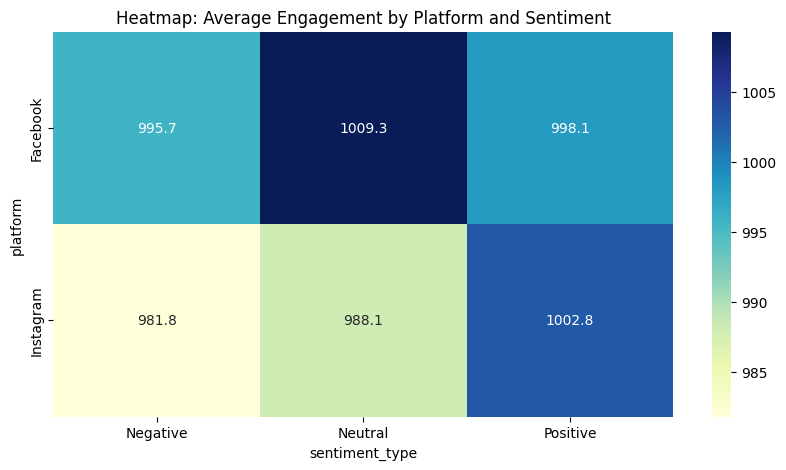

In [ ]:
# Create a pivot table to see average engagement per platform and sentiment
pivot_table = warehouse_df.pivot_table(values='engagement_score',
                                      index='platform',
                                      columns='sentiment_type',
                                      aggfunc='mean')

plt.figure(figsize=(10, 5))
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='.1f')
plt.title('Heatmap: Average Engagement by Platform and Sentiment')
plt.show()

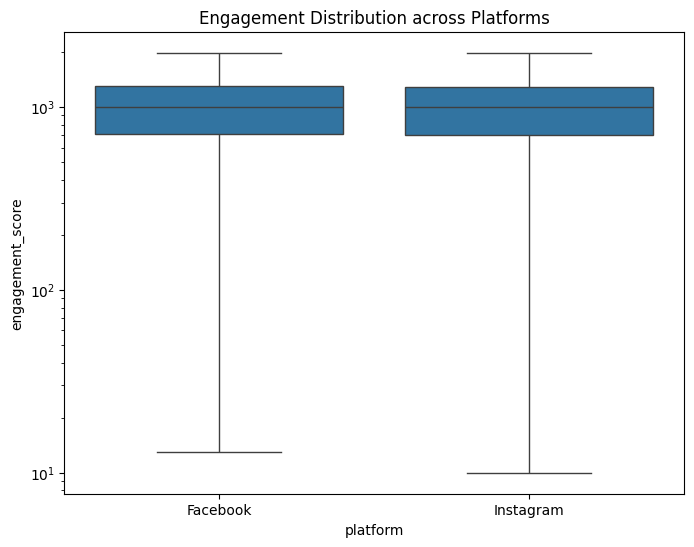

In [ ]:
# Boxplot for Comparative Analysis
plt.figure(figsize=(8, 6))
sns.boxplot(x='platform', y='engagement_score', data=warehouse_df)
plt.title('Engagement Distribution across Platforms')
plt.yscale('log') # Using log scale if scores vary widely
plt.show()

In [ ]:
# Final output to check results
print("\nFinal Data Summary:")
print(warehouse_df.groupby(['platform', 'sentiment_type']).size().unstack())


Final Data Summary:
sentiment_type  Negative  Neutral  Positive
platform                                   
Facebook             737      637      6327
Instagram            746      618      6654


/tmp/ipython-input-400437189.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(warehouse_df.groupby(['platform', 'sentiment_type']).size().unstack())
